In [1]:
# Create a folder to hold your data
!mkdir padel_dataset

# Download the file (replace the URL with the exact one you copied)
!wget "https://zenodo.org/records/14653706/files/padel-data-labels.zip?download=1" -O padel_dataset/data.zip

# Unzip it into your new folder
!unzip padel_dataset/data.zip -d padel_dataset/

--2026-05-06 18:51:43--  https://zenodo.org/records/14653706/files/padel-data-labels.zip?download=1
Resolving zenodo.org (zenodo.org)... 137.138.153.219, 137.138.52.235, 188.185.48.75, ...
Connecting to zenodo.org (zenodo.org)|137.138.153.219|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7143110555 (6.7G) [application/octet-stream]
Saving to: ‘padel_dataset/data.zip’

padel_dataset/data. 100%[===================>]   6.65G  16.9MB/s    in 6m 15s  

2026-05-06 18:57:59 (18.1 MB/s) - ‘padel_dataset/data.zip’ saved [7143110555/7143110555]

Archive:  padel_dataset/data.zip
  inflating: padel_dataset/2022_BCN_FinalM_1.mp4  
   creating: padel_dataset/labels/
  inflating: padel_dataset/labels/2022_BCN_FinalF_1_ball.json  
  inflating: padel_dataset/labels/2022_BCN_FinalF_1_pose.json  
  inflating: padel_dataset/labels/2022_BCN_FinalF_1_shots.csv  
  inflating: padel_dataset/labels/2022_BCN_FinalM_1_shots.csv  
  inflating: padel_dataset/labels/2022_BCN_FinalM_1_pos

In [3]:
!pip install -q numpy pandas scikit-learn xgboost matplotlib seaborn

In [ ]:
import json
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')


LABELS_DIR = "padel_dataset/labels"

DATASETS = [
    {
        "name": "FinalF_1",
        "pose": f"{LABELS_DIR}/2022_BCN_FinalF_1_pose.json",
        "shots": f"{LABELS_DIR}/2022_BCN_FinalF_1_shots.csv",
    },
    {
        "name": "FinalM_1",
        "pose": f"{LABELS_DIR}/2022_BCN_FinalM_1_pose.json",
        "shots": f"{LABELS_DIR}/2022_BCN_FinalM_1_shots.csv",
    },
]

# HELPER FUNCTIONSs
def load_pose_json(path):
    """Load COCO-format pose JSON and return a DataFrame with one row per annotation."""
    with open(path, "r") as f:
        data = json.load(f)
    
    df = pd.DataFrame(data["annotations"])
    
    # Map image_id -> file_name so we can extract frame numbers
    img_map = {img["id"]: img["file_name"] for img in data["images"]}
    df["file_name"] = df["image_id"].map(img_map)
    df["frame_id"] = df["file_name"].apply(lambda x: int(x.split("_")[1].split(".")[0]))
    
    # Get the skeleton definition (same for all annotations)
    categories = data.get("categories", [])
    skeleton = categories[0].get("skeleton", []) if categories else []
    df["skeleton"] = [skeleton] * len(df)
    
    return df


def load_shot_csv(path):
    """Load the semicolon-separated shot CSV."""
    df = pd.read_csv(path, sep=";", encoding="utf8")
    df["frame_id"] = df["file_name"].apply(lambda x: int(x.split("_")[1].split(".")[0]))
    return df


all_samples = []

for ds in DATASETS:
    print(f"Loading {ds['name']}...")
    
    pose_df = load_pose_json(ds["pose"])
    shot_df = load_shot_csv(ds["shots"])
    
    # Keep only frames where a shot IS happening and we know the category
    shot_frames = shot_df[
        (shot_df["has_shot"] == True) & 
        (shot_df["category"].notna()) & 
        (shot_df["category"] != "0") &
        (shot_df["category"] != 0)
    ][["frame_id", "category"]].drop_duplicates()
    
    # Merge: for each shot frame, get all player poses in that frame
    merged = pd.merge(shot_frames, pose_df, on="frame_id", how="inner")
    merged["match"] = ds["name"]
    all_samples.append(merged)
    
    print(f"  Pose annotations: {len(pose_df)}")
    print(f"  Shot frames with known category: {len(shot_frames)}")
    print(f"  Merged samples (pose + shot): {len(merged)}")

df_all = pd.concat(all_samples, ignore_index=True)

print(f"\n{'='*50}")
print(f"Total merged samples: {len(df_all)}")
print(f"\nShot type distribution:")
print(df_all["category"].value_counts())


Loading FinalF_1...
  Pose annotations: 183744
  Shot frames with known category: 7502
  Merged samples (pose + shot): 30013
Loading FinalM_1...
  Pose annotations: 215173
  Shot frames with known category: 5748
  Merged samples (pose + shot): 22992

Total merged samples: 53005

Shot type distribution:
category
Forehand    15461
Backhand    13517
Smash       12895
Serve        6936
Other        3832
Dropshot      364
Name: count, dtype: int64


In [5]:
kp_col = None
for col in ["keypoints", "keypoints_x"]:
    if col in df_all.columns:
        kp_col = col
        break

if kp_col is None:
    print("ERROR: Could not find a keypoints column. Available columns:")
    print(df_all.columns.tolist())
else:
    print(f"Using keypoints column: '{kp_col}'")

# Build X and y
X_list = []
y_list = []
skipped = 0

for idx, row in df_all.iterrows():
    kp = row[kp_col]
    
    # Handle cases where keypoints might be stored as a string
    if isinstance(kp, str):
        kp = json.loads(kp)
    
    if not isinstance(kp, list) or len(kp) < 3:
        skipped += 1
        continue
    
    # COCO keypoints format: [x1, y1, v1, x2, y2, v2, ...]
    # We take ONLY x and y (drop the visibility flag 'v')
    # This gives us 17 joints * 2 coords = 34 features
    coords = []
    for i in range(0, len(kp), 3):
        coords.append(kp[i])      # x
        coords.append(kp[i + 1])  # y
    
    X_list.append(coords)
    y_list.append(row["category"])

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list)

print(f"\nFeature matrix X shape: {X.shape}  (samples, features)")
print(f"Label array y shape:   {y.shape}")
print(f"Skipped {skipped} rows with missing keypoints")
print(f"\nLabel distribution:")
for label in np.unique(y):
    print(f"  {label}: {np.sum(y == label)}")


Using keypoints column: 'keypoints'

Feature matrix X shape: (53005, 34)  (samples, features)
Label array y shape:   (53005,)
Skipped 0 rows with missing keypoints

Label distribution:
  Backhand: 13517
  Dropshot: 364
  Forehand: 15461
  Other: 3832
  Serve: 6936
  Smash: 12895


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Encode string labels to numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Evaluate
y_pred = rf_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\n{'='*50}")
print(f"Random Forest Accuracy: {acc:.4f} ({acc*100:.1f}%)")
print(f"{'='*50}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Classes: ['Backhand' 'Dropshot' 'Forehand' 'Other' 'Serve' 'Smash']
Train: 42404 samples
Test:  10601 samples

Random Forest Accuracy: 0.9326 (93.3%)

Detailed Classification Report:
              precision    recall  f1-score   support

    Backhand       0.93      0.93      0.93      2703
    Dropshot       0.98      0.82      0.90        73
    Forehand       0.91      0.94      0.92      3092
       Other       0.96      0.82      0.89       767
       Serve       0.98      0.99      0.98      1387
       Smash       0.93      0.94      0.94      2579

    accuracy                           0.93     10601
   macro avg       0.95      0.91      0.93     10601
weighted avg       0.93      0.93      0.93     10601



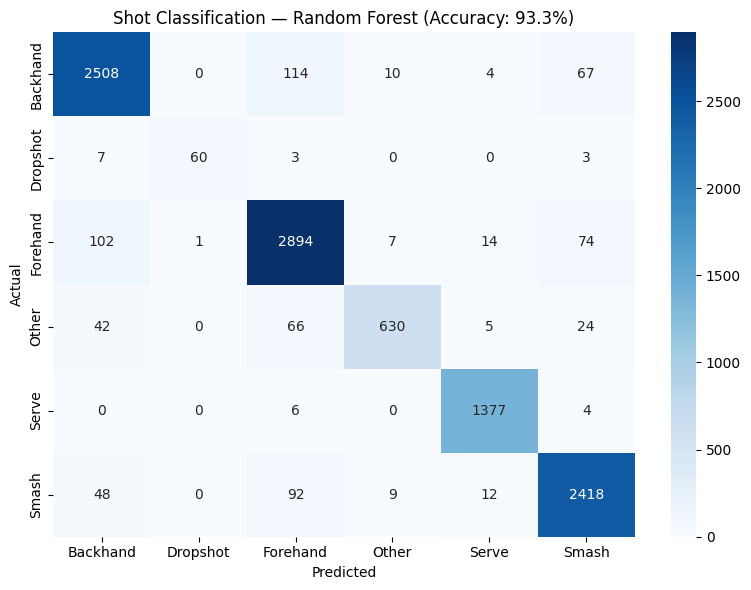

In [7]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Shot Classification — Random Forest (Accuracy: {acc*100:.1f}%)")
plt.tight_layout()
plt.savefig("confusion_matrix_rf.png", dpi=150)
plt.show()


In [8]:
import pickle

# Save the trained model and the label encoder
with open("shot_classifier_rf.pkl", "wb") as f:
    pickle.dump({"model": rf_model, "label_encoder": le}, f)

print("Model saved as 'shot_classifier_rf.pkl'")
print("Download this file from Kaggle -> Output -> shot_classifier_rf.pkl")


Model saved as 'shot_classifier_rf.pkl'
Download this file from Kaggle -> Output -> shot_classifier_rf.pkl


In [10]:
import pickle, cv2, json
import numpy as np
import pandas as pd

#model is loaded
with open("shot_classifier_rf.pkl", "rb") as f:
    saved = pickle.load(f)
rf, le = saved["model"], saved["label_encoder"]

#annotations are loaded
VIDEO_PATH = "padel_dataset/2022_BCN_FinalF_1_sample.mp4"
POSE_PATH  = "padel_dataset/labels/2022_BCN_FinalF_1_pose.json"

with open(POSE_PATH) as f:
    pose_raw = json.load(f)

img_lookup = {img["id"]: img["file_name"] for img in pose_raw["images"]}
pose_df = pd.DataFrame(pose_raw["annotations"])
pose_df["file_name"] = pose_df["image_id"].map(img_lookup)
pose_df["frame_id"] = pose_df["file_name"].apply(lambda x: int(x.split("_")[1].split(".")[0]))
kp_col = "keypoints" if "keypoints" in pose_df.columns else "keypoints_x"
pose_groups = pose_df.groupby("frame_id")

cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS)
w, h = int(cap.get(3)), int(cap.get(4))
writer = cv2.VideoWriter("output_annotated.mp4", cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

shot_log = []
prev_shots = {} 
fid = 0

while True:
    ok, frame = cap.read()
    if not ok:
        break
    
    timestamp_sec = round(fid / fps, 3)
    mm = int(timestamp_sec // 60)
    ss = timestamp_sec % 60

    if fid in pose_groups.groups:
        players = pose_groups.get_group(fid)
        
        for player_idx, (_, row) in enumerate(players.iterrows()):
            kp = row[kp_col]
            if isinstance(kp, str):
                kp = json.loads(kp)
            if not isinstance(kp, list) or len(kp) < 3:
                continue

            # Build feature vector: x,y pairs only
            features = []
            for i in range(0, len(kp), 3):
                features.extend([kp[i], kp[i+1]])

            # Predict
            pred_idx = rf.predict([features])[0]
            shot_label = le.inverse_transform([pred_idx])[0]
            
            # Get confidence (probability of the predicted class)
            probs = rf.predict_proba([features])[0]
            confidence = round(float(probs.max()), 3)

            # Draw on frame
            if "bbox" in row and isinstance(row["bbox"], list):
                bx, by, bw, bh = [int(v) for v in row["bbox"]]
                color = {
                    "Forehand": (0, 255, 0), "Backhand": (255, 165, 0),
                    "Smash": (0, 0, 255), "Serve": (255, 255, 0),
                    "Dropshot": (255, 0, 255), "Other": (200, 200, 200)
                }.get(shot_label, (255, 255, 255))
                cv2.rectangle(frame, (bx, by), (bx+bw, by+bh), color, 2)
                cv2.putText(frame, f"{shot_label} ({confidence:.0%})", 
                           (bx, by - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

            # Log shot event (avoid duplicates: only log when shot changes)
            player_key = f"player_{player_idx+1}"
            if prev_shots.get(player_key) != shot_label:
                shot_log.append({
                    "frame_id": fid,
                    "timestamp_sec": timestamp_sec,
                    "timestamp": f"{mm:02d}:{ss:05.2f}",
                    "player": player_key,
                    "shot_type": shot_label,
                    "confidence": confidence
                })
                prev_shots[player_key] = shot_label

    writer.write(frame)
    fid += 1

cap.release()
writer.release()

# ---- Save to CSV ----
df_log = pd.DataFrame(shot_log)
df_log.to_csv("shot_analysis.csv", index=False)

# ---- Save to JSON ----
output_json = {
    "video": VIDEO_PATH,
    "total_frames": fid,
    "fps": fps,
    "duration_sec": round(fid / fps, 2),
    "total_shot_events": len(shot_log),
    "shot_summary": df_log["shot_type"].value_counts().to_dict(),
    "events": shot_log
}
with open("shot_analysis.json", "w") as f:
    json.dump(output_json, f, indent=2)

# ---- Print summary ----
print(f"Processed {fid} frames")
print(f"Logged {len(shot_log)} shot transition events")
print(f"\nShot distribution:")
print(df_log["shot_type"].value_counts().to_string())
print(f"\nFiles saved:")
print(f"  Video  -> output_annotated.mp4")
print(f"  CSV    -> shot_analysis.csv")
print(f"  JSON   -> shot_analysis.json")
print(f"\nSample entries:")
df_log.head(10)

Processed 407 frames
Logged 455 shot transition events

Shot distribution:
shot_type
Smash       179
Forehand    120
Backhand    109
Other        37
Serve        10

Files saved:
  Video  -> output_annotated.mp4
  CSV    -> shot_analysis.csv
  JSON   -> shot_analysis.json

Sample entries:


,frame_id,timestamp_sec,timestamp,player,shot_type,confidence
0,0,0.000,00:00.00,player_1,Serve,0.965
1,0,0.000,00:00.00,player_2,Serve,0.970
2,0,0.000,00:00.00,player_3,Serve,0.985
3,0,0.000,00:00.00,player_4,Serve,0.880
4,31,1.033,00:01.03,player_2,Forehand,0.470
5,31,1.033,00:01.03,player_3,Smash,0.350
6,32,1.067,00:01.07,player_2,Smash,0.390
7,32,1.067,00:01.07,player_3,Serve,0.515
8,32,1.067,00:01.07,player_4,Forehand,0.465
9,33,1.100,00:01.10,player_2,Forehand,0.565
